# 🎮 **STEAM PRICE INTELLIGENCE SYSTEM**

## 📌 **PROJECT OVERVIEW**

The **Steam Price Intelligence System** is a machine learning project that predicts game pricing using **only pre-release data**, simulating real-world decisions developers make before launch.

The model uses structured features like release year, achievements, and developer signals, along with **NLP on game descriptions** to understand gameplay scope and perceived value.

By focusing on pre-release information, the system provides a practical, data-driven approach to estimating game prices and understanding pricing patterns in the Steam marketplace.

---

## 🎯 **PROBLEM STATEMENT**

Pricing is one of the most critical decisions for indie game developers.

Many games may be:

* Underpriced, leaving potential revenue unrealized
* Overpriced, reducing sales volume
* Priced without sufficient data-driven insight

The objective of this project is to:

* Analyze historical Steam game data
* Identify key features that influence pricing
* Build regression and classification models
* Provide an intelligent price recommendation range based on game attributes

This system aims to help developers make strategic pricing decisions backed by machine learning insights.

---

# **01 – EXPLORATORY DATA ANALYSIS**

This notebook focuses on performing **Exploratory Data Analysis (EDA)** on the Steam dataset to understand its structure, pricing patterns, feature distributions, and potential data quality issues.

The objective of this phase is to:

* Explore dataset structure and feature types
* Identify missing values, outliers, and noise
* Analyze price distribution and skewness
* Examine relationships between pricing and key variables

The insights gained from this analysis guide the **feature engineering strategy** and inform the design of subsequent **modeling approaches**, including structured ML and NLP-based techniques.

---

In [1]:
'''Importing necessary libraries for data analysis and visualization.'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loading the dataset from the specified path into a DataFrame.
df = pd.read_csv(r'..\data\raw\games_march2025_cleaned.csv')

In [3]:
# Displaying the first few rows of the DataFrame to understand its structure and contents.
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


## **1.DATA OVERVIEW**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      89618 non-null  object 
 2   release_date              89618 non-null  object 
 3   required_age              89618 non-null  int64  
 4   price                     89618 non-null  float64
 5   dlc_count                 89618 non-null  int64  
 6   detailed_description      89421 non-null  object 
 7   about_the_game            89398 non-null  object 
 8   short_description         89498 non-null  object 
 9   reviews                   10401 non-null  object 
 10  header_image              89618 non-null  object 
 11  website                   41114 non-null  object 
 12  support_url               44110 non-null  object 
 13  support_email             78798 non-null  object 
 14  window

In [5]:
df.shape

(89618, 47)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
appid,89618.0,1.656904e+06,916838.982016,20.0,855052.50,1524730.00,2430852.50,3542350.00
required_age,89618.0,1.836238e-01,1.725594,-1.0,0.00,0.00,0.00,21.00
price,89618.0,7.309623e+00,13.331073,0.0,0.99,4.99,9.99,999.98
dlc_count,89618.0,5.955835e-01,15.351920,0.0,0.00,0.00,0.00,3427.00
metacritic_score,89618.0,2.903245e+00,14.445358,0.0,0.00,0.00,0.00,97.00
achievements,89618.0,2.055233e+01,163.562418,0.0,0.00,5.00,20.00,9821.00
recommendations,89618.0,1.009401e+03,22048.147658,0.0,0.00,0.00,0.00,4401572.00
user_score,89618.0,3.281707e-02,1.615149,0.0,0.00,0.00,0.00,100.00
score_rank,39.0,9.912821e+01,0.695076,98.0,99.00,99.00,100.00,100.00
positive,89618.0,1.269896e+03,31814.411404,0.0,1.00,10.00,58.00,7480813.00


### **KEY FINDINGS**

* The dataset contains **94,948 records and 47 features**, including numerical, categorical, boolean, and text-based fields.
* Several columns contain **missing values**, particularly in metadata-related fields.
* Some features include **negative placeholder values (e.g., -1)** indicating missing or undefined data.
* The target variable **price is highly right-skewed**, with extreme outliers (max ≈ 999.98).
* Engagement-related features (reviews, playtime, recommendations) show **long-tail distributions and high variance**.

These findings highlight the need for **data cleaning, outlier handling, and feature transformation** before modeling.

## **2.MISSING VALUES AND DUPLICATE ANALYSIS**

In [7]:
df_null = df.isnull().sum()
df_null = df_null[df_null > 0] # Identify columns with null values
df_null

detailed_description      197
about_the_game            220
short_description         120
reviews                 79217
website                 48504
support_url             45508
support_email           10820
metacritic_url          86071
notes                   72975
score_rank              89579
dtype: int64

In [8]:
null_df = df.isnull().mean() * 100 > 50
null_df = null_df[null_df].index.tolist()
print("Columns with more than 50% null values:", null_df) # Identify columns with more than 50% null values

Columns with more than 50% null values: ['reviews', 'website', 'support_url', 'metacritic_url', 'notes', 'score_rank']


In [9]:
print(f"Number of duplicated appids: {df.duplicated(subset=['appid']).sum()}") # Check for duplicate appids

Number of duplicated appids: 0


### **KEY FINDINGS**

* **11 out of 47 columns** contain missing values.
* **6 columns have more than 50% missing data**, including:
  `reviews`, `website`, `support_url`, `metacritic_url`, `notes`, and `score_rank`.
* These high-null columns may require **removal or special handling** during preprocessing.
* No duplicate records were found based on the unique identifier (`appid`).

This analysis highlights the need for **missing value treatment and feature selection** before model development.

## **3.PRICE AND RATING DISTRIBUTION ANALYSIS**

In [10]:
eda_df = df.copy()

In [11]:
eda_df['price'].describe()

count    89618.000000
mean         7.309623
std         13.331073
min          0.000000
25%          0.990000
50%          4.990000
75%          9.990000
max        999.980000
Name: price, dtype: float64

In [12]:
# Creating a copy of the original DataFrame for exploratory data analysis (EDA) to avoid modifying the original dataset.
def price_category(price):
    """
    Categorizes price using data-driven bins (based on distribution).
    """

    if price == 0:
        return 'free'
    elif price <= 0.99:
        return 'budget'
    elif price <= 4.99:
        return 'low'
    elif price <= 9.99:
        return 'mid'
    else:
        return 'premium'

In [13]:
#  Applying the price_category function to the 'price' column to create a new column 'price_category' that categorizes the games based on their price.
eda_df['price_category'] = eda_df['price'].apply(price_category)

In [14]:
eda_df['price_category'].value_counts(normalize=True) * 100

price_category
low        32.661965
mid        21.301524
premium    18.947087
free       15.800397
budget     11.289027
Name: proportion, dtype: float64

In [15]:
print ("Number of free games:", (eda_df['price'] == 0).sum())
print ("Number of games over 500:", (eda_df['price'] > 500).sum())
print ("The most expensive game is:", eda_df.loc[eda_df['price'].idxmax(), 'name'], "with a price of $", eda_df['price'].max())
print ("The cheapest game is:", eda_df.loc[eda_df['price'].idxmin(), 'name'], "with a price of $", eda_df['price'].min())

Number of free games: 14160
Number of games over 500: 3
The most expensive game is: The Leverage Game Business Edition with a price of $ 999.98
The cheapest game is: Counter-Strike 2 with a price of $ 0.0


### 📊 **KEY FINDINGS**

* **75% of games are priced below $10**, confirming strong dominance of low-cost titles.
* **Free games make up ~15.8% (14,160 games)** — a notable segment, but not the majority.
* Price distribution is **highly right-skewed**, with a long tail due to extreme outliers.
* Only **3 games exceed $500**, with a maximum price of **$999.98**.
* Median (**$4.99**) and 75th percentile (**$9.99**) define clear pricing tiers in the market.
* The largest category is **standard (~32.7%)**, followed by mid and premium tiers.

---

## **4.FREE KEYWORD SIGNAL ANALYSIS**

In [16]:
all_genres = (
    df['genres']
    .fillna('')
    .str.split(',')
    .explode()
    .str.strip()
    .unique()
)

all_categories = (
    df['categories']
    .fillna('')
    .str.split(',')
    .explode()
    .str.strip()
    .unique()
)

all_tags = (
    df['tags']
       .fillna('')
       .str.split(',')
       .explode()
       .str.strip()
       .unique()
)
print("Free to Play in categories (exact)?", "Free to Play" in all_categories)
print("Free to Play in genres (exact)?", "Free to Play" in all_genres)
print("Free to Play in tags (exact)?", "Free to Play" in all_tags)

Free to Play in categories (exact)? False
Free to Play in genres (exact)? False
Free to Play in tags (exact)? False


In [17]:
# Genres
print("Genres containing 'free':")
print([g for g in all_genres if 'free' in g.lower()])

# Categories
print("Categories containing 'free':")
print([c for c in all_categories if 'free' in c.lower()])

# Tags
print("Tags containing 'free':")
print([t for t in all_tags if 'free' in t.lower()])

Genres containing 'free':
["'Free To Play']", "'Free To Play'", "['Free To Play'", "['Free To Play']"]
Categories containing 'free':
[]
Tags containing 'free':
["{'Free to Play': 59933", "{'Free to Play': 62868", "{'Free to Play': 2170", "{'Free to Play': 3512", "{'Free to Play': 15768", "{'Free to Play': 6063", "{'Free to Play': 36916", "{'Free to Play': 4129", "'Free to Play': 5342", "'Free to Play': 616", "'Free to Play': 1871", "{'Free to Play': 17278", "{'Free to Play': 2195", "'Free to Play': 7091", "'Free to Play': 963", "'Free to Play': 373", "{'Free to Play': 890", "'Free to Play': 1910", "'Free to Play': 1935", "'Free to Play': 98713", "{'Free to Play': 695", "{'Free to Play': 1304", "{'Free to Play': 494", "{'Free to Play': 2657", "'Free to Play': 460", "{'Free to Play': 627", "'Free to Play': 168", "'Free to Play': 917", "'Free to Play': 1489", "{'Free to Play': 3970", "{'Free to Play': 735", "'Free to Play': 9191", "{'Free to Play': 3953", "{'Free to Play': 2761", "{'Free 

In [18]:
experimental_df = df.copy()
experimental_df['is_free'] = experimental_df['price'].apply(lambda x: 1 if x == 0 else 0)
experimental_df['has_free_genre'] = experimental_df['genres'].str.contains('free', case=False, na=False)
experimental_df['has_free_categories'] = experimental_df['categories'].str.contains('free', case=False, na=False)
experimental_df['has_free_tags'] = experimental_df['tags'].str.contains('free', case=False, na=False)

print(f"{'-'*5}Genres{'-'*5}")
print(pd.crosstab(experimental_df['has_free_genre'], experimental_df['is_free']))
print(f"Mean of is_free for games with free genre: {experimental_df[experimental_df['has_free_genre']]['is_free'].mean()}")

print(f"{'-'*5}Categories{'-'*5}")
print(pd.crosstab(experimental_df['has_free_categories'], experimental_df['is_free']))
print(f"Mean of is_free for games with free categories: {experimental_df[experimental_df['has_free_categories']]['is_free'].mean()}")

print(f"{'-'*5}Tags{'-'*5}")
print(pd.crosstab(experimental_df['has_free_tags'], experimental_df['is_free']))
print(f"Mean of is_free for games with free tags: {experimental_df[experimental_df['has_free_tags']]['is_free'].mean()}")

-----Genres-----
is_free             0     1
has_free_genre             
False           75386  5365
True               72  8795
Mean of is_free for games with free genre: 0.9918800045111086
-----Categories-----
is_free                  0      1
has_free_categories              
False                75458  14160
Mean of is_free for games with free categories: nan
-----Tags-----
is_free            0      1
has_free_tags              
False          75170  10333
True             288   3827
Mean of is_free for games with free tags: 0.9300121506682868


### 📊 **KEY FINDINGS**

* The term **“Free to Play” is inconsistently formatted** across `genres`, `tags`, and `categories`, with no reliable exact match.
* **Genres** show a **very strong signal**, with ~99% of games containing “free” being free.
* **Tags** are also highly predictive, with ~93% accuracy in identifying free games.
* **Categories** provide **no meaningful signal** for detecting free games.
* Presence of “free” in metadata acts as a **direct indicator of pricing**, rather than an indirect feature.
* This highlights strong dependency on keyword-based signals within Steam metadata.

---

## **5.PRICE DISTRIBUTION VISUAL ANALYSIS**

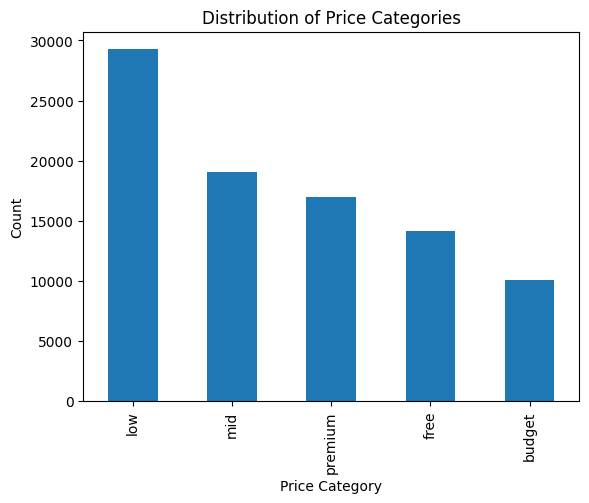

In [19]:
eda_df['price_category'].value_counts().plot(kind='bar')
plt.title('Distribution of Price Categories')
plt.xlabel('Price Category')
plt.ylabel('Count')
plt.show()

Text(0.5, 1.0, 'Box Plot of Game Prices')

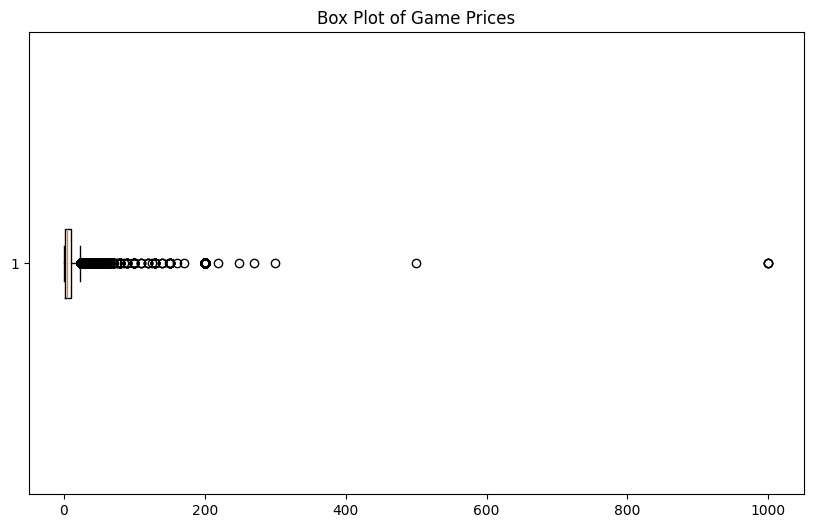

In [20]:
# box plot to visualize price distribution and outliers
plt.figure(figsize=(10, 6))
plt.boxplot(eda_df['price'],vert=False)
plt.title('Box Plot of Game Prices')

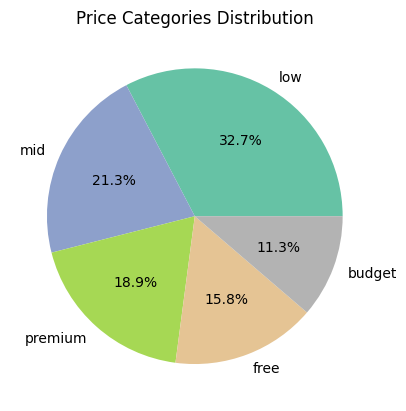

In [21]:
# plot pie chart for price range distribution
eda_df['price_category'].value_counts().plot(kind='pie', autopct='%1.1f%%',colormap='Set2')
plt.title('Price Categories Distribution')
plt.ylabel('')
plt.show()

### 📊 **KEY FINDINGS**

* **Low category (~32.7%) dominates**, followed by mid (~21.3%) and premium (~18.9%), showing most games fall in low-to-mid price ranges.
* **Free games (~15.8%)** represent a notable but not dominant segment.
* **Budget tier (~11.3%) is the smallest**, indicating fewer ultra-low priced (non-free) games.
* Price distribution is **highly right-skewed**, with most values concentrated at the lower end.
* The boxplot highlights **extreme outliers**, with a few games priced far beyond the typical range (up to ~$1000).
* Overall, the market follows a **long-tail distribution**, where a small number of high-priced games create large variance.

---

## 📌 **CONCLUSION – EDA**

The exploratory analysis provided a clear understanding of the dataset’s structure, pricing behavior, and data quality.

Key observations include:

* The dataset contains **94,948 records with no duplicate `appid` values**, ensuring data integrity.
* Several features contain **high missing values**, requiring removal or targeted preprocessing.
* Game prices are **highly right-skewed**, with most titles clustered in low-price ranges and a few extreme outliers.
* Pricing follows a **long-tail distribution**, where a small number of high-priced games create significant variance.
* The dataset includes both **structured features and textual descriptions**, enabling combined structured and NLP-based modeling approaches.

These insights establish a strong foundation for **feature engineering and model development** in the next phase.

---

### ✅ **PHASE 01 – EXPLORATORY DATA ANALYSIS COMPLETED**

➡ Moving to **Phase 02 – Data Preprocessing & Feature Engineering**

---